In [1081]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import defs

In [1082]:
pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 1000)
pd.set_option('display.max_colwidth', 100)

In [1083]:
df = pd.read_csv('../data/_data.csv', encoding='utf-8', index_col=0)

In [1084]:
df.columns=['Ad_ID', 'Number_of_rooms', 'Type', 'Metro', 'Address',
 'Area_m2', 'Building', 'Parking', 'Price', 'Phones', 'Description',
 'Renovation', 'Room_area_m2', 'Balcony', 'Windows', 'Bathroom',
 'Children/pets_allowed', 'Additional', 'Residential_complex_name',
 'Building_series', 'Ceiling_height_m', 'Elevator', 'Garbage_chute',
 'Ad_link']

In [1085]:
df['Number_of_rooms'] = df['Number_of_rooms'].apply(lambda x : defs.cutter(x,','))


In [1086]:
df.groupby('Number_of_rooms').count()

,Ad_ID,Type,Metro,Address,Area_m2,Building,Parking,Price,Phones,Description,Renovation,Room_area_m2,Balcony,Windows,Bathroom,Children/pets_allowed,Additional,Residential_complex_name,Building_series,Ceiling_height_m,Elevator,Garbage_chute,Ad_link
Number_of_rooms,,,,,,,,,,,,,,,,,,,,,,,
1,7931,7931,7488,7931,7931,7931,3094,7931,7931,7931,7105,5183,5257,5608,7061,4967,7808,1747,713,4016,6264,4850,7931
2,8466,8466,8026,8466,8466,8466,3456,8466,8466,8466,7424,5471,5938,6098,7533,6695,8345,1708,836,4232,6367,4846,8466
3,4262,4262,4039,4262,4262,4262,2012,4262,4262,4262,3644,2500,2866,3121,3764,3701,4203,1131,466,1949,3313,2182,4262
4,1163,1163,1121,1163,1163,1163,656,1163,1163,1163,1003,677,628,860,1035,1001,1145,411,102,483,865,461,1163
5,367,367,354,367,367,367,190,367,367,367,307,180,204,277,319,308,359,149,32,148,271,106,367
6,138,138,136,138,138,138,75,138,138,138,126,67,80,109,125,115,136,34,6,57,94,38,138


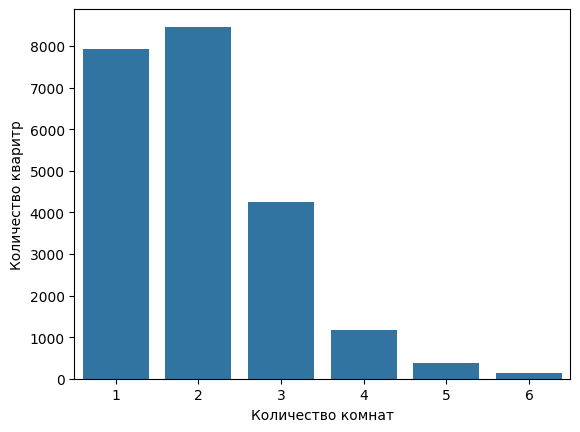

In [1087]:
fig, ax = plt.subplots()
sns.barplot(data = df.groupby('Number_of_rooms', as_index=False).count() , x ='Number_of_rooms', y = 'Ad_ID' )
ax.set_xlabel('Количество комнат')
ax.set_ylabel('Количество кваритр')
plt.show()


### Garbage_chute

In [1088]:
# df["Garbage_chute"] = df["Garbage_chute"].replace({"Да":1, "Нет":0})
df["Garbage_chute(yes)"] = df["Garbage_chute"].eq("Да")
df["Garbage_chute(no)"] = df["Garbage_chute"].eq("Нет")

df["Garbage_chute(yes)"] = df["Garbage_chute(yes)"].astype(int)
df["Garbage_chute(no)"] = df["Garbage_chute(no)"].astype(int)

### Ceiling_height_m

In [1089]:
df.loc[df["Ceiling_height_m"] > 100, "Ceiling_height_m"] /= 100
df.loc[df["Ceiling_height_m"] > 24.9, "Ceiling_height_m"] /= 10

df["Ceiling_height_m"] = df["Ceiling_height_m"][(df["Ceiling_height_m"] > 2.4) & (df["Ceiling_height_m"] < 6)]

### Elevator

In [1090]:
df["pass_elev"] = df["Elevator"].str.extract(r"Пасс\s*\((\d+)\)").fillna(0).astype(int)
df["cargo_elev"] = df["Elevator"].str.extract(r"Груз\s*\((\d+)\)").fillna(0).astype(int)
df["elevator_more_2"] = (df["pass_elev"]+df["cargo_elev"] >= 2).astype(int)


### f

In [1091]:
df = df.drop(["Elevator", "Residential_complex_name", "Building_series", "Garbage_chute"], axis=1)

In [1092]:
# df["year_built"] = df["Residential_complex_name"].str.extract(r".*[^0-9](\d{4})$")
# df["Residential_complex_name"] = df["Residential_complex_name"].str.extract(r"(.*)\D\d{4}$")

In [1093]:
# df["Garbage_chute"].isna().value_counts()
# df["Residential_complex_name"].unique()

# New

In [1094]:
# Additional
df["Additional"] = df["Additional"].fillna("1").str.split(",").apply(lambda x: [i.strip() for i in x])
df2 = df.explode("Additional")
dummies = pd.get_dummies(df2["Additional"])
dummies = dummies.groupby(df2.index).max()
dummies = dummies.astype(int)
df = pd.concat([df, dummies], axis=1)

df = df.rename(columns={
    "Ванна":"Bath",
    "Душевая кабина":"Shower_cabin",
    "Интернет":"Internet",
    "Кондиционер":"Conditioner",
    "Мебель в комнатах":"Furniture_in_rooms",
    "Мебель на кухне":"Furniture_in_kitchen",
    "Посудомоечная машина":"Dishwasher",
    "Стиральная машина":"Washer",
    "Телевизор":"TV",
    "Телефон":"Telephone",
    "Холодильник":"Fridge"
})


In [1095]:
df["low_ceilings"] = (df["Ceiling_height_m"] <= 3).astype(int)
df["high_ceilings"] = (df["Ceiling_height_m"] > 3).astype(int)

df["pass_elev"] = df["pass_elev"].fillna(0)

df = df[df["cargo_elev"] < 5]
df = df[df["pass_elev"] < 5]

In [1096]:
df = df.drop(columns=["Additional", "1", "Ceiling_height_m"])

In [ ]:
df["extra_money"] = df["extra_money"].fillna("1").str.split(",").apply(lambda x: [i.strip() for i in x])
df2 = df.explode("extra_money")
dummies = pd.get_dummies(df2["extra_money"])
dummies = dummies.groupby(df2.index).max()
dummies = dummies.astype(int)
df = pd.concat([df, dummies[["Коммунальные услуги включены", "Предоплата 1 мес", "Срок аренды - Длительный"]]], axis=1)
df = df.rename(columns={
    "Коммунальные услуги включены":"Utilities_included",
    "Предоплата 1 мес": "prepayment_1month",
    "Срок аренды - Длительный": "rental_period_long"

    })